Pattern Recognition Homework 1 - 
=

In [99]:
import sys
print(sys.executable)
print(sys.prefix)

/home/simonque/Documents/code/env/bin/python3
/home/simonque/Documents/code/env


# Import Required Libraries

In [36]:
import numpy as np
import matplotlib.pyplot as plt

In [37]:
'''
debug print
'''
DEBUG = True

def printd(*args, **kwargs):
    if DEBUG:
        print(*args, **kwargs)

# Generate Data

The data is 3-dimensional with three classes with specified means and covariance matrix, and some uninformative noise dimensions generated with zero mean and a specified variance.

In [38]:
# Specify dimensions, number of clases, and number of samples per class
dimensions = 3
num_classes = 3
num_samples_per_class = 100



In [39]:
#define class means
class_means = np.array([[2,2,0],
                       [-2,2,0],
                       [0,-2,0]], 
                       dtype=np.float32)
class_means

array([[ 2.,  2.,  0.],
       [-2.,  2.,  0.],
       [ 0., -2.,  0.]], dtype=float32)

In [40]:
# define covariance matrix among the classes
covariance = np.array([[1.0, 0.6,0],
                             [0.6, 1.5, 0],
                             [0,0,0.5]],
                            dtype=np.float32)
covariance

array([[1. , 0.6, 0. ],
       [0.6, 1.5, 0. ],
       [0. , 0. , 0.5]], dtype=float32)

## Generate Synthetic Random Multivariate Data

In [41]:
# generate the data for three classes
# set random seed
rng = np.random.default_rng(seed=25)

# generate standard normal samples 
sample_data = []
for i in range(num_classes):
    sample_data.append(rng.standard_normal((num_samples_per_class, dimensions)))
printd(sample_data[0].min(), sample_data[0].max(), sample_data[0].shape)

# use Cholesky decomposition to decompose the covariance matrix into the product
# of a lower triangular matrix and its transpose.
L = np.linalg.cholesky(covariance)
printd(L)
printd(L @ L.T)
printd(covariance)

# transform the data with the mean and covariance
for i in range(num_classes):
    sample_data[i] = class_means[i] + sample_data[i] @ L.T
    printd(f"Class {i}: ", sample_data[i].mean(axis=0), sample_data[i].min(axis=0), sample_data[i].max(axis=0))

-2.4453801820724297 3.370023181831863 (100, 3)
[[1.         0.         0.        ]
 [0.6        1.0677078  0.        ]
 [0.         0.         0.70710677]]
[[1.         0.6        0.        ]
 [0.6        1.4999999  0.        ]
 [0.         0.         0.49999997]]
[[1.  0.6 0. ]
 [0.6 1.5 0. ]
 [0.  0.  0.5]]
Class 0:  [2.02018937 2.05819058 0.02195273] [-0.33032588 -1.32226032 -1.62813087] [4.80219183 4.60543534 2.3829662 ]
Class 1:  [-1.942207    2.11459581 -0.04157584] [-4.20463215 -0.56963855 -2.06626432] [0.31253754 4.35711082 1.71750176]
Class 2:  [ 0.0267686  -1.93596624  0.05470097] [-1.92595512 -4.45886364 -1.3995467 ] [2.07664018 0.42973087 1.7808716 ]


## Generate Random Noise

In [42]:
# generate noise 
# set random seed
rng = np.random.default_rng(seed=25)

noise_mean = 0.0
noise_stdev = np.sqrt(0.5)
num_noise_dimensions = 10

noise = rng.normal(loc=noise_mean, scale=noise_stdev, size = (num_samples_per_class, num_noise_dimensions))
printd(noise.mean(axis=0), noise.std(axis=0))
printd(noise.shape)

[-0.05022312  0.07142925  0.21043292 -0.05672072  0.05493059 -0.03212811
  0.01259905  0.05112516 -0.01823378  0.04938577] [0.62054322 0.72132359 0.72661286 0.60863727 0.70006698 0.68620548
 0.74514741 0.65150861 0.7048021  0.77921413]
(100, 10)


## Mahalanobis distance

In [43]:
from scipy.spatial import distance 

inv_covariance = np.linalg.pinv(covariance)
# x is a point
# d = distance.mahalanobis(x, mean, inv_covariance)


## Plot the data in 2D

Mahalanobis distance
$$
D_M(x,y) = \sqrt{(x-y)^T\Sigma^{-1}(x-y)}
$$

In [90]:
def visualize_mahalanobis_distances(x: np.array, 
                                    y: np.array, 
                                    inv_covariance: np.array, 
                                    class_means: np.array, 
                                    plot:bool = False,
                                    return_vals:bool = True):
    # create 2D coordinate grid
    x_grid = np.linspace(x.min() - 1, x.max() + 1, 300)
    y_grid = np.linspace(y.min() - 1, y.max() + 1, 300)
    printd(f"x_grid.shape = {x_grid.shape}")
    printd(f"y_grid.shape = {y_grid.shape}")
    XX, YY = np.meshgrid(x_grid, y_grid)
    printd(f"XX.shape = {XX.shape}")
    printd(f"YY.shape = {YY.shape}")
    grid_points = np.c_[XX.ravel(), YY.ravel()]
    printd(f"grid_points.shape = {grid_points.shape}")
    
    print(f"inv_covariance.shape = {inv_covariance.shape}")
    
    # calculate Mahalanobis distance with the difference between the grid points and the mean
    # and the inverse of the covariance matrix
    diff = grid_points - class_means
    printd(f"diff.shape = {diff.shape}")
    # slice the covariance matrix to get the covariance between two dimensions 
    
    # t = np.dot(diff, inv_covariance[np.ix_(idx, idx)]) * diff
    # print(t.shape) # (40000,2), sum across the two dimensions (axis = 1)
    dist_sq = np.sum(np.dot(diff, inv_covariance) * diff, axis=1)
    printd(f"dist_sq.shape = {dist_sq.shape}")
    dist_grid = np.sqrt(dist_sq).reshape(XX.shape)
    print(f"dist_grid.shape = {dist_grid.shape}")
    print(f"{dist_grid.min()}, {dist_grid.max()}")

    if plot == True:
        fig, ax = plt.subplots(figsize=(7, 5))
        cax = ax.imshow(dist_grid, cmap="viridis", interpolation="nearest", aspect="auto", origin="lower")
        
        # 3. Add colorbar, labels, and title
        fig.colorbar(cax, label="Intensity")
        ax.set_title("Mahalanobis distance plot test visualization")
        ax.set_xlabel("X Axis")
        ax.set_ylabel("Y Axis")
        
        plt.tight_layout()
        plt.show()

    if return_vals == True:
        return (XX, YY, dist_grid)

x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.01090837688598761, 7.260068805752606


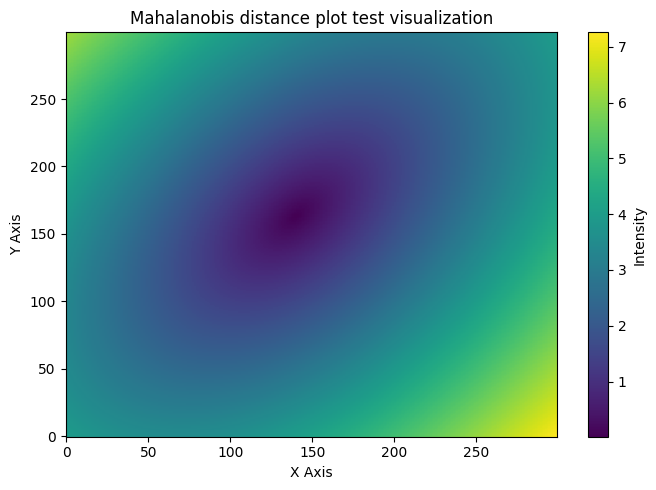

In [91]:
class_num = 0
x = sample_data[class_num][:,0]
y = sample_data[class_num][:,1]
idx = [0,1]
inv_cov = inv_covariance[np.ix_(idx, idx)]
class_mean = class_means[class_num][np.ix_(idx)]
visualize_mahalanobis_distances(x,y,inv_cov,class_mean, plot=True, return_vals = False)

x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.0016736846505597252, 6.169474254339443


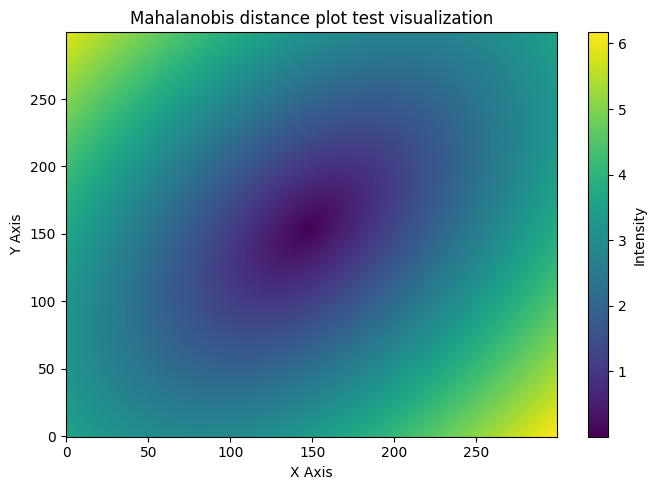

In [92]:
class_num = 1
x = sample_data[class_num][:,0]
y = sample_data[class_num][:,1]
idx = [0,1]
inv_cov = inv_covariance[np.ix_(idx, idx)]
class_mean = class_means[class_num][np.ix_(idx)]
visualize_mahalanobis_distances(x,y,inv_cov, class_mean, plot=True, return_vals = False)

x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.0076394141275085035, 5.843899502617392


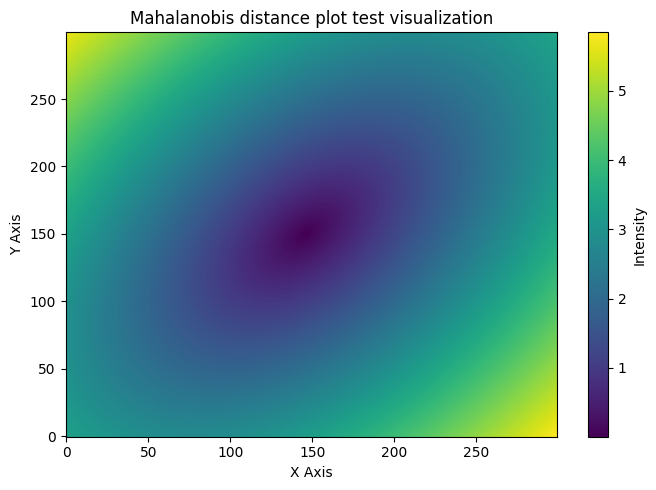

In [93]:
class_num = 2
x = sample_data[class_num][:,0]
y = sample_data[class_num][:,1]
idx = [0,1]
inv_cov = inv_covariance[np.ix_(idx, idx)]
class_mean = class_means[class_num][np.ix_(idx)]
visualize_mahalanobis_distances(x,y,inv_cov, class_mean, plot=True, return_vals = False)

idx = [0, 1]
x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.01090837688598761, 7.260068805752606
x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.0016736846505597252, 6.169474254339443
x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)
dist_sq.shape = (90000,)
dist_grid.shape = (300, 300)
0.0076394141275085035, 5.843899502617392
idx = [1, 2]
x_grid.shape = (300,)
y_grid.shape = (300,)
XX.shape = (300, 300)
YY.shape = (300, 300)
grid_points.shape = (90000, 2)
inv_covariance.shape = (2, 2)
diff.shape = (90000, 2)

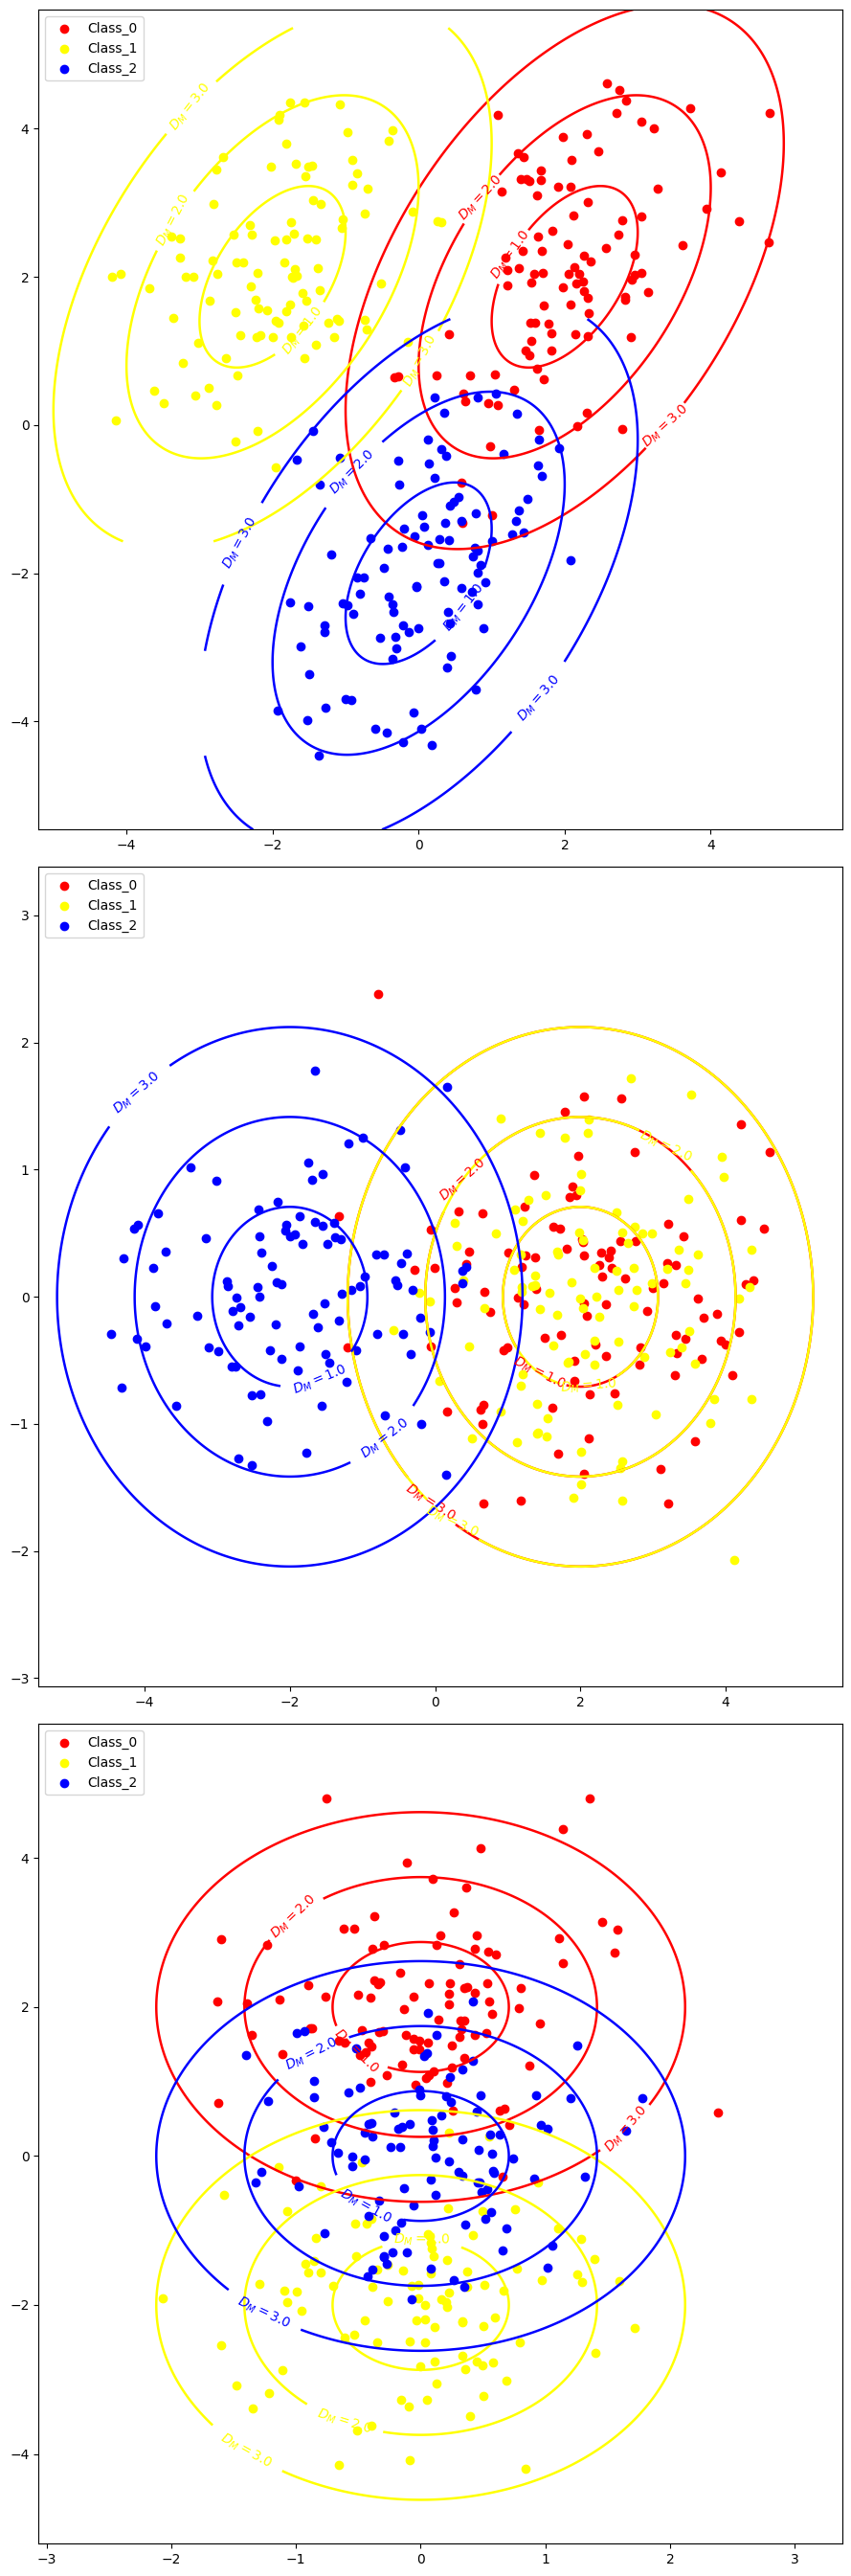

In [123]:
fig, ax = plt.subplots(nrows=3,figsize = (9,27))
colors = ['red', 'yellow', 'blue']

for i in range(3): 
    idx = [i, (i+1)%3]
    print(f"idx = {idx}")

    for class_num in range(num_classes):
        x = sample_data[class_num][:,idx[0]]
        y = sample_data[class_num][:,idx[1]]
        ax[i].scatter(x, y, label = f"Class_{class_num}", color = colors[class_num])
        inv_cov = inv_covariance[np.ix_(idx, idx)]
        class_mean = class_means[class_num][np.ix_(idx)]
        (XX, YY, dist_grid) = visualize_mahalanobis_distances(x,y,inv_cov, class_mean)
        # draw the contours of the Mahalanobis distances
        levels = [0,1,2,3]
        cs = ax[i].contour(XX, YY, dist_grid, levels = levels, colors =colors[class_num], linewidths=1.8)
        # cs = ax[i].contourf(XX, YY, dist_grid, levels = levels, colors =colors[class_num], alpha=0.8)
        ax[i].clabel(cs, inline=True, fmt=r'$D_M = %.1f$', fontsize=10)
    ax[i].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 3D scatter plot with 95%-confidence ellipsoids

In [116]:
import plotly.graph_objects as go
# from scipy.stats import chi2
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook"

In [117]:
sample_data[0].shape

(100, 3)

In [122]:
fig = go.Figure()

class_names = ["class_0", "class_1", "class_2"]
colors = ['red', 'yellow', 'blue']
for i, arr, name, color in zip(range(3), sample_data, class_names, colors):
    print(i)
    fig.add_trace(go.Scatter3d(
        x=sample_data[i][:,0],
        y = sample_data[i][:,1],
        z = sample_data[i][:,2],
        mode = "markers",
        name=name,
        marker = dict(color = color,
                        size=3,
                     opacity= 0.95)
    ))
# px.scatter_3d(
#                    )
# fig.update_traces()

# fig = px.scatter_3d(x=sample_data[1][:,0],
#                     y = sample_data[1][:,1],
#                     z = sample_data[1][:,2],
#                    )
# fig.update_traces(marker = dict(color = "yellow",
#                                 size=5))
fig.show()

0
1
2


In [ ]:
# 95% critical value for chi-squared, 3 degrees of freedom
chi2_val = chi2.ppf(0.95, df = 3)
radii = np.sqrt(chi2_val * evals)

# Hughes' Phenomenon

# Spatial whitening with PCA and Ridge Regularization

# Supervised Dimensionality Reduction

# Iris Dataset Experiment